In [ ]:
# Ячейка № 1

# вычисление численных решений
# выбранной колебательной системы
# под действием внешней силы,
# приложенной к выбранной массе

# подключение библиотеки numpy
import numpy as np

# подключение библиотеки matplotlib
import matplotlib.pyplot as plt

# подключение библиотеки ScalarFormatter
from matplotlib.ticker import ScalarFormatter

# подключаем функции fft, fftfreq
from scipy.fft import fft, fftfreq

# подключение метода solve_ivp из библиотеки scipy.integrate
from scipy.integrate import solve_ivp


In [2]:
# Ячейка № 2

# задание функции, возвращающей значения
# вынуждающей силы, приложенной к одной из масс
# колебательной системы
def FV(t):
    return A * np.sin(OmegaFV * t)


In [3]:
# Ячейка № 3

# задание функции, возвращающей значения
# первых производных СДУ (9.27)
def Deriv(t, x):
    z = np.zeros(2 * N)
    z[0] = x[1]
    z[1] = (
        -Omega[0, 0] * x[0]
        - Omega[1, 0] * (x[0] - x[2])
        + Alpha_m[1, 0] * (x[0] - x[2]) ** 2
        - Alpha_m[0, 0] * x[0] ** 2
        + Beta_m[1, 0] * (x[0] - x[2]) ** 3
        - Beta_m[0, 0] * x[0] ** 3
    )
    if Nball == 0:
        z[1] = z[1] + FV(t)
    K = 2
    for i in range(N - 2):
        z[K] = x[K + 1]
        z[K + 1] = (
            -Omega[i + 1, i + 1] * (x[K] - x[K - 2])
            - Omega[i + 2, i + 1] * (x[K] - x[K + 2])
            + Alpha_m[i + 2, i + 1] * (x[K] - x[K + 2]) ** 2
            - Alpha_m[i + 1, i + 1] * (x[K] - x[K - 2]) ** 2
            + Beta_m[i + 2, i + 1] * (x[K] - x[K + 2]) ** 3
            - Beta_m[i + 1, i + 1] * (x[K] - x[K - 2]) ** 3
        )
        if (Nball > 0) & (Nball < N - 2):
            z[K + 1] = z[K + 1] + FV(t)
        K = K + 2
    z[2 * N - 2] = x[2 * N - 1]
    z[2 * N - 1] = (
        -Omega[N - 1, N - 1] * (x[2 * N - 2] - x[2 * N - 4])
        - Omega[N, N - 1] * x[2 * N - 2]
        + Alpha_m[N, N - 1] * x[2 * N - 2] ** 2
        - Alpha_m[N - 1, N - 1] * (x[2 * N - 2] - x[2 * N - 4]) ** 2
        + Beta_m[N, N - 1] * x[K - 2] ** 3
        - Beta_m[N - 1, N - 1] * (x[2 * N - 2] - x[2 * N - 4]) ** 3
    )
    if Nball == N - 1:
        z[2 * N - 1] = z[2 * N - 1] + FV(t)

    return z

In [ ]:
# Ячейка № 3

# вычисление численных решений
# выбранной колебательной системы
# под действием внешней силы,
# приложенной к выбранной массе

# задание числа масс
# колебательной системы
N = 16

# задание значений масс
# колебательной системы
m = np.ones(N)

# задание жесткостей пружин
# колебательной системы
k = np.ones(N + 1)

# вычисление матрицы Omega
Omega = np.zeros([N + 1, N])

for i in range(N + 1):
    for j in range(N):
        Omega[i, j] = k[i] / m[j]

# инициализация массива omega,
# используемого для хранения
# матрицы omega, вычисляемой
# в соответствии с (9.8)
omega = np.zeros([N, N])

# вычисление вычисление значений
# элементов матрицы Omega
# в соответствие с (9.8)
for i in range(N):
    if i == 0:
        omega[0, 0] = Omega[0, 0] + Omega[1, 0]
        omega[0, 1] = -Omega[1, 0]
    if i > 0:
        if i < N - 1:
            omega[i, i - 1] = -Omega[i, i]
            omega[i, i] = Omega[i, i] + Omega[i + 1, i]
            omega[i, i + 1] = -Omega[i + 1, i]
        else:
            omega[i, i - 1] = -Omega[i, i]
            omega[i, i] = Omega[i, i] + Omega[i + 1, i]

# задание коэффициентов
# квадратичных составляющих нелинейностей
# пружин колебательной системы
# для задания нулевых значений
# коэффициентов квадратичных нелинейностей
# заменить в следующей строчке ones на zeros и наоборот
alpha = 0.2 * np.zeros(N + 1)

# инициализация массива Alpha_m,
# используемого для хранения отношений
# квадратических составляющих нелинейностей
# жесткостей пружин к массам тел
# колебательной системы
Alpha_m = np.zeros([N + 1, N])

# вычисление значений отношений
# коэффициентов квадратичных нелинейностей
# к массам грузов
for i in range(N + 1):
    for j in range(N):
        Alpha_m[i, j] = alpha[i] / m[j]

# задание коэффициентов
# кубических составляющих нелинейностей
# пружин колебательной системы
# для задания нулевых значений
# коэффициентов кубических нелинейностей
# заменить в следующей строчке ones на zeros и наоборот
beta = 0.1 * np.zeros(N + 1)

Beta_m = np.zeros([N + 1, N])

# вычисление значений отношений
# коэффициентов кубических нелинейностей
# к массам грузов
for i in range(N + 1):
    for j in range(N):
        Beta_m[i, j] = beta[i] / m[j]

# вычисление собственных чисел и
# собственных векторов матрицы Omеga,
# элементы которой вычисляются
# в соответствие с (9.4)
Teta, Sigma = np.linalg.eig(omega)

# вычисление матрицы, обратной
# матрице omega
S = np.linalg.inv(omega)

R0 = np.zeros(N)
V0 = np.zeros(N)

# инициализация и заполнение массива Nu,
# используемого для хранения начальных условий
# в формате, используемым в функции Solv_inv
Nu = np.zeros(2 * N)
for i in range(N):
    Nu[2 * i] = R0[i]
    Nu[2 * i + 1] = V0[i]

# задание шага
# координатной сетки
Tfin = 100
Np = 2**21
dt = Tfin / Np

# задание параметров вынуждающей силы

# задание циклической частоты
# вынуждающей силы, приложенной
# к одной из масс колебательной системы
OmegaFV = 3

# вынуждающей силы
A = 0.25

# задание номера массы, к которой
# приложена внешняя вынуждающая сила
Nball = 0

# вычисление численного решения СДУ (9.27)
Solv = solve_ivp(Deriv, [0, Tfin], Nu, method="RK45", t_eval=np.linspace(0, Tfin, Np))


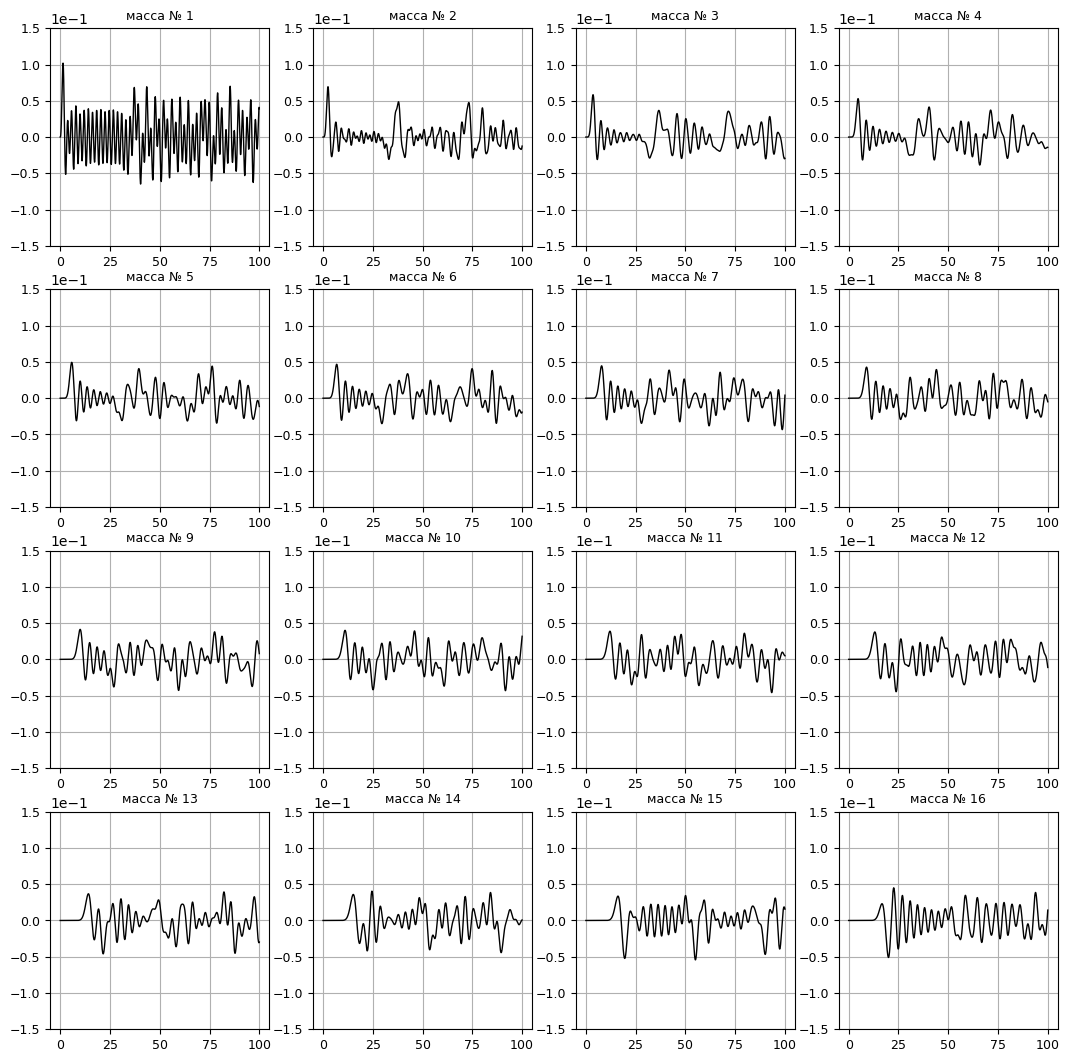

In [5]:
# Ячейка № 4

# визуализация мгновенных значений
# зависимостей смещений от их положения равновесия
# масс изучаемой колебательной системы
# от времени

# визуализация зависимостей
# смещений масс колебательной системы
# от их положений равновесия от времени
fig = plt.figure(figsize=(13, 13))

K = 0
for i in range(N):
    Str = "масса № " + str(K + 1)
    ax = fig.add_subplot(4, 4, K + 1)
    ax.grid(True)
    ax.plot(Solv.t[:], Solv.y[2 * K, :], "-k", lw=1)
    ax.set_ylim(-0.15, 0.15)

    # задание формата нумерации
    # делений ординат
    sf = ScalarFormatter()
    sf.set_powerlimits((-1, 1))
    ax.yaxis.set_major_formatter(sf)

    ax.set_title(Str, fontsize=9)
    ax.tick_params(labelsize=9)
    K = K + 1

plt.show()

In [6]:
# Ячейка № 5

# вычисление мгновенных зависимостей
# координат мод нормальных колебаний
# от времени

# вычисление собственных чисел и
# собственных векторов матрицы omеga
Teta, Sigma = np.linalg.eig(omega)

# инициализация массива Teta_M,
# используемого для создания
# диагональной матрицы, в которой
# на главной диагонали размещаются с
# соответствующие собственные числа матрицы B
Teta_M = np.zeros([N, N])

# размещение на главной диагонали матрицы Teta_M
# соответствующих собственных чисел матрицы B
for i in range(N):
    Teta_M[i, i] = np.sqrt(Teta[i])

# вычисление матрицы,
# обратной матрице Sigma
Sx = np.linalg.inv(Sigma)

# перемещение численного
# решения СДУ (9.30) из массива размерностью N x Np
# в массив размерностью Np x N
Y1 = Solv.y.T

# инициализация массива X2,
# используемого для хранения мгновенных значений
# смещений от положения равновесия
# масс колебательной системы
X2 = np.zeros([Np, N])

# инициализация массива V2,
# используемого для хранения мгновенных значений
# скоростей масс колебательной системы
V2 = np.zeros([Np, N])

# перемещение значений координат и
# скоростей масс колебательной системы
# в массивы X2 и V2, соответственно
for i in range(N):
    X2[:, i] = Y1[:, 2 * i]
    V2[:, i] = Y1[:, 2 * i + 1]


# инициализация массива Xn,
# используемого для хранения
# координат мгновенных значений
# нормальных колебаний
# масс колебательной системы
Xn = np.zeros([Np, N])

# инициализация массива Vn,
# используемого для хранения мгновенных значений
# скоростей нормальных колебаний
Vn = np.zeros([Np, N])

# вычисление мгновенных значений
# координат и скоростей колебательной системы
# в соответствие с (9.31)
for i in range(Np):
    Xn[i, :] = np.dot(Sx, X2[i, :])
    Vn[i, :] = np.dot(Sx, V2[i, :])

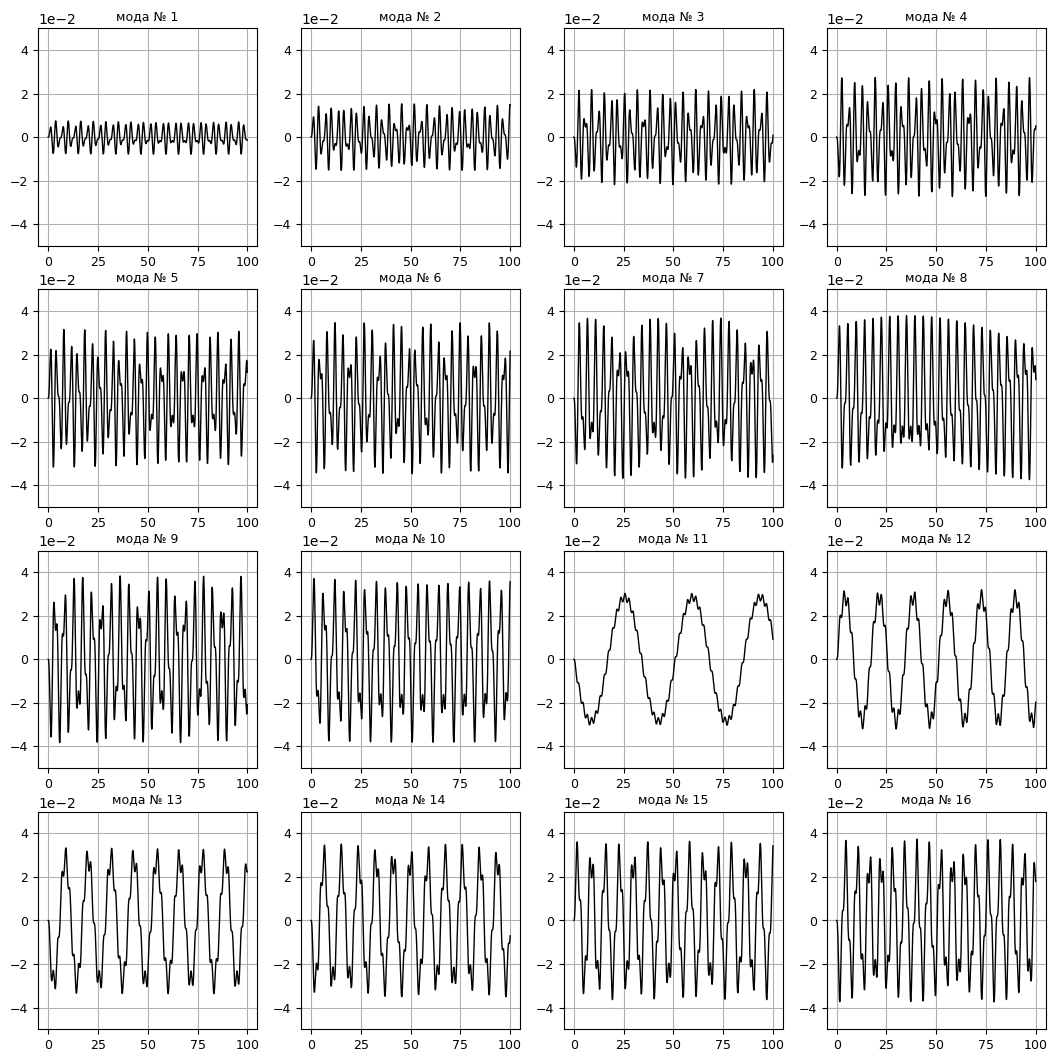

In [7]:
# Ячейка № 6

# визуализация мгновенных значений
# зависимостей мгновенных мод
# колебательной системы от времени

fig = plt.figure(figsize=(13, 13))

K = 0
for i in range(N):
    Str = "мода № " + str(K + 1)
    ax = fig.add_subplot(4, 4, K + 1)
    ax.grid(True)
    ax.plot(Solv.t[:], Xn[:, K], "-k", lw=1)
    ax.set_ylim(-0.05, 0.05)

    # задание формата нумерации
    # делений ординат
    sf = ScalarFormatter()
    sf.set_powerlimits((-1, 1))
    ax.yaxis.set_major_formatter(sf)

    ax.set_title(Str, fontsize=9)
    ax.tick_params(labelsize=9)
    K = K + 1

plt.show()

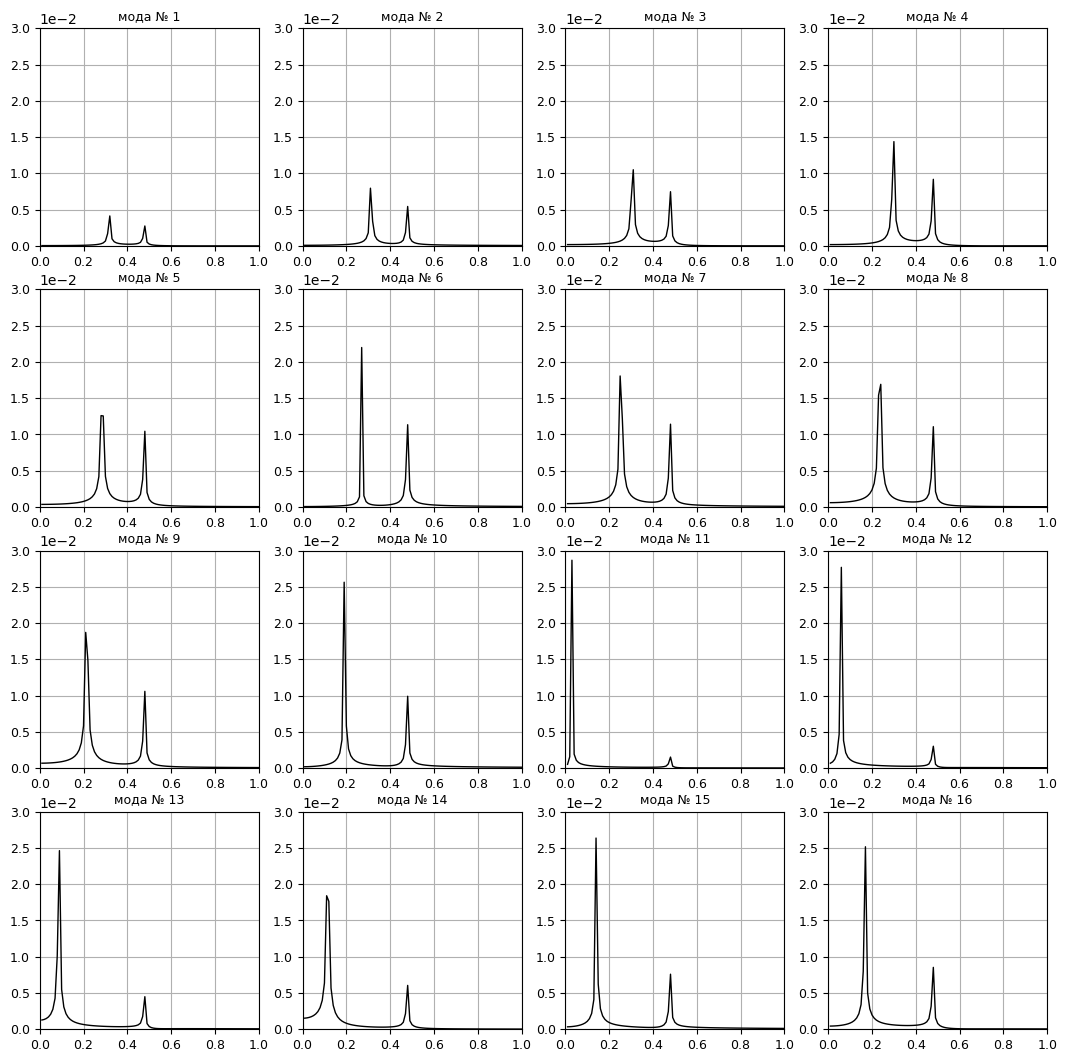

In [ ]:
# Ячейка № 7

# вычисление и визуализация спектров
# зависимостей координат
# мод нормальных колебаний от времени

# вычисление частот спектральных гармоник
Freq = fftfreq(Np, dt)

# вычисление спектров
# зависимостей координат
# мод нормальных колебаний от времени

# вычисление значения
# наибольшего номера
# информативной спектральной гармоники
N2 = round((Np - 1) / 2) - 1

# вычисление значений
# частот информативных гармоник
Freq_R = np.zeros(N2)
for i in range(N2):
    Freq_R[i] = Freq[i + 1]

# инициализация массива C_R1
# используемого для хранения
# спектра данной моды нормальных колебаний
c_R1 = np.zeros(N2)

# инициализация массива S,
# используемого для хранения
# информативных значений спектров
# каждой из мод нормальных
S = np.zeros([N2, N])

# вычисление спектров
# зависимостей координат
# мод нормальных колебаний от времени
for i in range(N):
    # вычисление спектра i-ой
    #  моды нормальных колебаний
    c1 = fft(Xn[:, i])

    # выделение информативной части
    # спектра i-ой моды
    # нормальных колебаний
    for j in range(N2):
        c_R1[j] = np.abs(2 * c1[j + 1]) / Np

    # размещение значений
    # информативной части спектра
    # i-ой моды нормальных колебаний
    #  в массиве S
    S[:, i] = c_R1[:].T


# визуализация спектров
# зависимостей мод нормальных колебаний
# от времени
fig = plt.figure(figsize=(13, 13))

K = 0
for i in range(N):
    Str = "мода № " + str(K + 1)
    ax = fig.add_subplot(4, 4, K + 1)
    ax.grid(True)
    ax.plot(Freq_R, S[:, K], "-k", lw=1)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 0.03)

    # задание формата нумерации
    # делений на оси ординат
    sf = ScalarFormatter()
    sf.set_powerlimits((-1, 1))
    ax.yaxis.set_major_formatter(sf)
    ax.set_title(Str, fontsize=9)
    ax.tick_params(labelsize=9)
    K = K + 1

plt.show()

In [9]:
print(np.sqrt(Teta[:]) / (2 * np.pi))

[0.31695203 0.31289006 0.30615861 0.29681513 0.28493933 0.27063252
 0.25401677 0.23523384 0.21444398 0.19182456 0.02936993 0.05848929
 0.08710964 0.11498679 0.14188293 0.16756856]


In [10]:
print(OmegaFV / (2 * np.pi))

0.477464829275686
